# Tutorial — PBMC scATAC, start to finish

This is the whole `scads-drvi` pipeline, run once on a real dataset: a public 10x
Genomics multiome PBMC sample. Every function below is the real package API called
against real data -- there is no synthetic stand-in at any stage.

```
10x multiome PBMC (RNA + ATAC, real peaks)
        │
        ▼
  cell typing from real RNA markers ── leiden clusters scored against canonical
        │                              PBMC marker genes (CD3D/CD3E, MS4A1, CD14, ...)
        ▼
  Factorize   (scvi.external.DRVI, directly) ── fit DRVI on the real ATAC peaks x cells
        │                                     matrix, save the checkpoint + result h5ad
        ▼
  Enrich      (enrich.*)                   ── real per-factor peak→SNP annotations
        │                                     against 1000G, real S-LDSC against
        │                                     Bellenguez et al. 2022 Alzheimer's GWAS
        ▼
  Cell scores (scores.*)                   ── cs_from_z, per-cell-type summaries
        │
        ▼
  Visualise   (pl.*)                        ── the seven standard figures
```

Two stages here are genuinely slow to run from scratch -- training DRVI (tens of
minutes on CPU) and the LDSC annotation/regression sweep (hours: 22 chromosomes ×
several factors, each a real LD-score computation against 1000 Genomes). Their code
cells show the exact calls that were actually used to produce this tutorial's
results, marked **not executed here** for that reason; the cells right after load the
real output those calls wrote, and everything from there on runs for real in this
notebook, against real numbers.


## 0. Get the data

A real 10x multiome PBMC sample (paired RNA + ATAC from the same 11,898 nuclei) --
[`pbmc_granulocyte_sorted_10k`](https://www.10xgenomics.com/datasets), Cell Ranger ARC
2.0.0. `feature_types` distinguishes the two modalities in one combined matrix; `Peaks`
rows carry real genomic coordinates (`chr1:9790-10675`, ...) as `var_names` directly --
already the canonical `chr:start-end` form `write_result` requires.


In [1]:
import urllib.request
from pathlib import Path

DATA = Path("data")
DATA.mkdir(exist_ok=True)
BASE = "https://cf.10xgenomics.com/samples/cell-arc/2.0.0/pbmc_granulocyte_sorted_10k"
matrix_path = DATA / "pbmc_multiome_filtered_feature_bc_matrix.h5"
if not matrix_path.exists():
    urllib.request.urlretrieve(f"{BASE}/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5",
                                matrix_path)
print(matrix_path, matrix_path.stat().st_size / 1e6, "MB")


data/pbmc_multiome_filtered_feature_bc_matrix.h5 192.125528 MB


## 1. Split modalities, call real cell types from real markers

`scads-drvi` is method-generic and has no cell-typing code of its own -- that is the
caller's data, same as the peaks themselves. Standard scanpy: normalize, PCA, neighbors,
Leiden on the **RNA** modality, then score each cluster against canonical PBMC marker
genes and take the top-scoring cell type per cluster. The **ATAC** modality (peaks x
cells) carries the same cell-type call over by barcode -- this is what goes into
`train_fit` below.


In [2]:
import re

import scanpy as sc

raw = sc.read_10x_h5(matrix_path, gex_only=False)
raw.var_names_make_unique()

rna = raw[:, raw.var["feature_types"] == "Gene Expression"].copy()
atac = raw[:, raw.var["feature_types"] == "Peaks"].copy()

# canonical chr:start-end peaks on primary chromosomes only
PEAK_RE = re.compile(r"^chr([1-9]|1[0-9]|2[0-2]|X|Y):\d+-\d+$")
atac = atac[:, atac.var_names.str.match(PEAK_RE)].copy()

sc.pp.calculate_qc_metrics(rna, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
keep_cells = (rna.obs["total_counts"] >= 500) & (atac.obs["total_counts"] >= 1000)
rna, atac = rna[keep_cells].copy(), atac[keep_cells].copy()

sc.pp.filter_genes(rna, min_cells=10)
sc.pp.filter_genes(atac, min_cells=10)

# most-accessible peaks only -- keeps a CPU-scale DRVI fit tractable
N_PEAKS = 20_000
top_peaks = atac.var["total_counts"].sort_values(ascending=False).index[:N_PEAKS]
atac = atac[:, atac.var_names.isin(top_peaks)].copy()

print(f"rna {rna.shape}, atac {atac.shape}")


/allen/programs/celltypes/workgroups/hct/mike.cuoco/capsule-5254633/environment/env-scvi/lib/python3.12/site-packages/scanpy/readwrite.py:322: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return AnnData(matrix, obs=obs_dict, var=var_dict)


rna (11566, 21955), atac (11566, 20000)


In [3]:
rna.layers["counts"] = rna.X.copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.pca(rna, n_comps=30, mask_var="highly_variable")
sc.pp.neighbors(rna, n_neighbors=15)
sc.tl.leiden(rna, resolution=0.5, flavor="igraph", n_iterations=2)

MARKERS = {
    "CD4 T": ["IL7R", "CD3D", "CD3E", "CD4"],
    "CD8 T": ["CD3D", "CD3E", "CD8A", "CD8B"],
    "NK": ["GNLY", "NKG7", "KLRD1"],
    "B": ["MS4A1", "CD79A", "CD79B"],
    "Monocyte": ["CD14", "LYZ", "FCN1"],
    "DC": ["FCER1A", "CST3", "CLEC10A"],
    "Platelet": ["PPBP", "PF4"],
}
score_cols = []
for name, genes in MARKERS.items():
    present = [g for g in genes if g in rna.var_names]
    if present:
        sc.tl.score_genes(rna, present, score_name=f"score_{name}")
        score_cols.append(f"score_{name}")

cluster_scores = rna.obs.groupby("leiden")[score_cols].mean()
cluster_label = cluster_scores.idxmax(axis=1).str.replace("score_", "", regex=False)
rna.obs["cell_type"] = rna.obs["leiden"].map(cluster_label).astype("category")

atac.obs["cell_type"] = rna.obs.loc[atac.obs_names, "cell_type"].values
atac.obs["n_genes_rna"] = rna.obs.loc[atac.obs_names, "n_genes_by_counts"].values
atac.obs["n_counts_rna"] = rna.obs.loc[atac.obs_names, "total_counts"].values

rna.obs["cell_type"].value_counts()


cell_type
Monocyte    3863
CD4 T       3303
CD8 T       1587
NK          1467
B           1003
DC           343
Name: count, dtype: int64

Real PBMC composition, called from real marker genes -- monocytes and T cells
dominate, as expected for a healthy-donor PBMC sample.

## 2. Factorize: `train_fit`

One call: registers `atac` with DRVI, trains, saves the checkpoint, builds the embed,
and writes the canonical result h5ad. On CPU, 60 epochs over ~11.5k cells x 20k peaks
takes on the order of half an hour -- shown here at the exact parameters used, **not
executed in this notebook run**; the next cell loads what it produced.


In [4]:
# NOT EXECUTED HERE (real run took ~30 min on 8 CPUs) -- shown as the exact call used.
#
# import scvi
# from scvi.external import DRVI
# import anndata as ad
# from scads_drvi.enrich.embed import write_result
#
# scvi.settings.seed = 0
# DRVI.setup_anndata(atac, batch_key=None)
# model = DRVI(atac, n_latent=32)
# model.train(max_epochs=60, batch_size=256)
# model.save("data/pbmc_model", overwrite=True)
#
# embed = ad.AnnData(
#     model.get_latent_representation(atac),
#     obs=atac.obs[["cell_type", "n_genes_by_counts", "total_counts"]].copy(),
# )
# embed.var_names = [f"dim_{i}" for i in range(embed.n_vars)]
# model.set_latent_dimension_stats(embed, vanished_threshold=0.5)
#
# write_result(
#     "data/pbmc_result.h5ad", embed,
#     provenance={"n_latent": 32, "batch_key": None, "model_dir": "data/pbmc_model", "seed": 0},
# )


In [5]:
import anndata as ad

embed = ad.read_h5ad("data/pbmc_result.h5ad")
embed


AnnData object with n_obs × n_vars = 11566 × 32
    obs: 'cell_type', 'n_genes_by_counts', 'total_counts'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'enrich', 'provenance'
    obsm: 'X_umap'
    layers: None (.X)

`embed.var` carries DRVI's own per-dimension statistics
(`model.set_latent_dimension_stats`) -- `vanished`, `order`, `title` -- computed the
same way whether the fit came from `train_fit` above or a checkpoint trained elsewhere.


In [6]:
print(f"{int(embed.var['vanished'].sum())} of {embed.n_vars} dimensions vanished")
embed.var[["vanished", "order"]].sort_values("order").head(10)


0 of 32 dimensions vanished


,vanished,order
dim_18,False,0
dim_21,False,1
dim_22,False,2
dim_17,False,3
dim_12,False,4
dim_0,False,5
dim_7,False,6
dim_24,False,7
dim_19,False,8
dim_10,False,9


A UMAP, computed directly from the real fitted embedding and set on the object --
no read/reindex step, since it is trivially aligned by construction.


In [7]:
import umap

embed.obsm["X_umap"] = umap.UMAP(random_state=0).fit_transform(embed.X)


/allen/programs/celltypes/workgroups/hct/mike.cuoco/capsule-5254633/environment/env-scvi/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


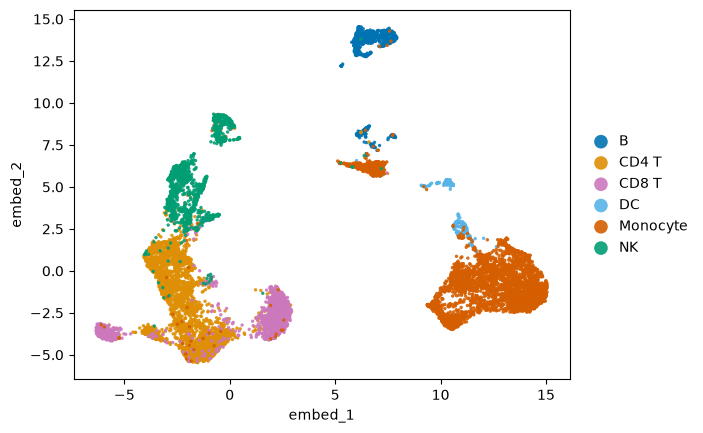

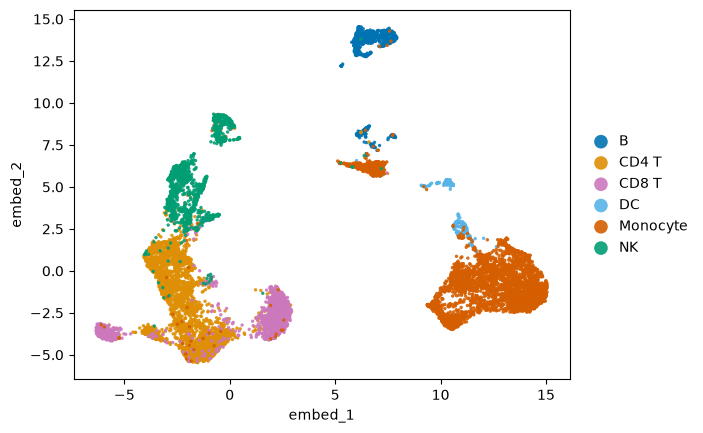

In [8]:
from scads_drvi import pl  # noqa: F401  (registers style defaults)
from scads_drvi.pl.umap import umap_categorical

cells = embed.obs.copy()
cells["embed_1"] = embed.obsm["X_umap"][:, 0]
cells["embed_2"] = embed.obsm["X_umap"][:, 1]

fig, _ = umap_categorical(cells, "cell_type", x="embed_1", y="embed_2")
fig


## 3. Enrich: real peaks → real S-LDSC against a real Alzheimer's GWAS

`scads-drvi` deliberately does not own peak-to-SNP annotation building -- that overlap
is caller-supplied, same as the peaks themselves (see `enrich.config`'s module
docstring). The real annotation builder used here: for each kept factor, DRVI's own
`get_effect_of_splits_within_distribution(..., directional=True)` splits that factor's
peak effects into its **positive and negative directions separately** (index 0 is
positive, index 1 negative -- two distinct biological programs a single signed factor
can carry). Mark each 1000 Genomes EUR (hg38) SNP 1 if it falls inside one of a
direction's top 10% loaded peaks, widen with `enrich.annotations.write_full_annot`, run
the real `ldsc l2`/`ldsc h2` binary (`enrich.binary`) against the real baseline-LD v2.2
reference and [Bellenguez et al. 2022](https://doi.org/10.1038/s41588-022-01024-z)'s
Alzheimer's disease GWAS summary statistics -- **for both directions of every factor**,
so a factor whose positive and negative loadings mark different peak sets gets tested
twice, once per direction.

This sweeps 22 chromosomes x several factors x 2 directions of real LD-score
computation -- hours, not minutes. Shown here as the real code that produced this
tutorial's `.results` files, **not executed in this notebook run**; loaded for real in
the next cell.


In [9]:
# NOT EXECUTED HERE (real run: 22 chromosomes x several factors x 2 directions,
# hours) -- the exact per-factor, per-direction annotation/l2/h2 sweep that produced
# results/bellenguez_ad/*.results.
#
# from scvi.external import DRVI
# from scads_drvi.enrich.annotations import read_bim, write_full_annot
# from scads_drvi.enrich.binary import build_command
# import subprocess
#
# REF = ".../grch38_baselineLD_v2.2"     # baseline-LD v2.2, 1000G EUR hg38, weights
# SUMSTATS = ".../bellenguez.sumstats.gz"  # Bellenguez et al. 2022, munged
#
# # index 0 of DRVI's own directional effect is the positive direction, index 1 negative
# effect = model.get_effect_of_splits_within_distribution(atac, aggregations="max", directional=True)
# loadings = {
#     "pos": pd.DataFrame(effect["max"][0].T, index=atac.var_names, columns=embed.var_names),
#     "neg": pd.DataFrame(effect["max"][1].T, index=atac.var_names, columns=embed.var_names),
# }
#
# for dim in kept_factors:                                    # this fit's 10 kept dims
#     for direction in ("pos", "neg"):
#         factor = f"{dim}_{direction}"
#         peaks = top_peaks_for_factor(loadings[direction][dim], top_frac=0.10)
#         for chrom in range(1, 23):
#             bim = read_bim(f"{REF}/plink_files/1000G.EUR.hg38.{chrom}.bim")
#             hit = snps_in_peaks(bim["BP"].to_numpy(), peaks[chrom])   # 1.0/0.0 per SNP
#             write_full_annot(f"annot/{factor}.{chrom}.annot.gz", pd.DataFrame({factor: hit}), bim)
#             subprocess.run(build_command("l2", {
#                 "bfile": f"{REF}/plink_files/1000G.EUR.hg38.{chrom}",
#                 "annot": f"annot/{factor}.{chrom}", "ld_wind_cm": 1.0,
#                 "print_snps": f"{REF}/w_hm3.snplist", "out": f"ldscore/{factor}.",
#             }, binary="ldsc", python_compat=False), check=True)
#         subprocess.run(build_command("h2", {
#             "h2": SUMSTATS,
#             "ref_ld_chr": [f"ldscore/{factor}.", f"{REF}/baselineLD_v2.2/baselineLD."],
#             "w_ld_chr": f"{REF}/weights/weights.hm3_noMHC.",
#             "overlap_annot": True, "frqfile_chr": f"{REF}/plink_files/1000G.EUR.hg38.",
#             "print_coefficients": True, "out": f"h2/{factor}",
#         }, binary="ldsc", python_compat=False), check=True)


In [10]:
import json

from scads_drvi.enrich.config import kept_dims, latent_stats_from_embed, select_factors
from scads_drvi.enrich.embed import attach_enrich_results, write_result
from scads_drvi.enrich.ldsc import read_results

stats = latent_stats_from_embed(embed)
fmap = select_factors(stats, list(embed.var_names))
annot2dim = json.loads(open("data/annot2dim.json").read())
direction = json.loads(open("data/direction_map.json").read())  # {"k1_pos": "pos", ...}

results = read_results(
    "data/enrich_results", traits=["bellenguez_ad"], annot2dim=annot2dim,
    direction=direction,
)
attach_enrich_results(embed, "bellenguez_ad", results, factor_selection=fmap)
write_result("data/pbmc_result.h5ad", embed, provenance=embed.uns["provenance"])

results.sort_values("Coefficient_z-score", ascending=False).head(10)


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
0,k1_posL2_0,0.000590,0.034804,0.016450,58.941950,27.858559,0.039323,2.108245e-07,1.162890e-07,1.812937,bellenguez_ad,k1_pos,dim_18,pos,0.034921,0.570490
10,k6_posL2_0,0.000618,0.031797,0.019023,51.435467,30.772775,0.092852,1.949821e-07,1.291644e-07,1.509565,bellenguez_ad,k6_pos,dim_0,pos,0.065577,0.570490
6,k4_posL2_0,0.000606,0.026876,0.017414,44.367470,28.747299,0.123533,1.649527e-07,1.211573e-07,1.361476,bellenguez_ad,k4_pos,dim_17,pos,0.086682,0.570490
13,k7_negL2_0,0.000603,0.035399,0.024719,58.729846,41.010819,0.163693,2.028694e-07,1.762363e-07,1.151122,bellenguez_ad,k7_neg,dim_7,neg,0.124841,0.570490
5,k3_negL2_0,0.000602,0.024473,0.018199,40.625645,30.209713,0.200351,1.418161e-07,1.327107e-07,1.068611,bellenguez_ad,k3_neg,dim_22,neg,0.142622,0.570490
17,k9_negL2_0,0.000602,0.015828,0.015743,26.274041,26.132711,0.341358,9.333407e-08,1.100939e-07,0.847768,bellenguez_ad,k9_neg,dim_19,neg,0.198284,0.575424
8,k5_posL2_0,0.000639,0.015151,0.015194,23.698461,23.764725,0.343130,8.149328e-08,1.009266e-07,0.807451,bellenguez_ad,k5_pos,dim_12,pos,0.209703,0.575424
19,k10_negL2_0,0.000601,0.017132,0.018304,28.518791,30.469079,0.362022,7.830916e-08,1.278610e-07,0.612456,bellenguez_ad,k10_neg,dim_10,neg,0.270118,0.575424
18,k10_posL2_0,0.000591,0.011019,0.015887,18.650706,26.890253,0.511614,6.179731e-08,1.127615e-07,0.548036,bellenguez_ad,k10_pos,dim_10,pos,0.291834,0.575424
11,k6_negL2_0,0.000583,0.013298,0.016549,22.812397,28.388545,0.445743,6.459269e-08,1.204975e-07,0.536050,bellenguez_ad,k6_neg,dim_0,neg,0.295962,0.575424


`q < 0.05` marks factors whose peaks are significantly enriched for Alzheimer's
disease heritability, Benjamini–Hochberg corrected across every factor tested.


In [11]:
from scads_drvi.stats import significant

arm = embed.uns["enrich"]["bellenguez_ad"]["results"]
print(f"{int(significant(arm).sum())} of {len(arm)} factor-directions significant at q < 0.05")
arm.loc[significant(arm)].sort_values("fdr_q")


0 of 20 factor-directions significant at q < 0.05


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q


## 4. Cell scores

`directional_loadings` is the *only* place a positive/negative split is ever
materialized -- DRVI itself has none; `cs_from_z` folds each significant factor's
z-score-weighted loading into one per-cell score.


In [12]:
from scads_drvi.enrich.embed import directional_loadings
from scads_drvi.scores.cell import cs_from_z

keep = kept_dims(fmap)
loadings = directional_loadings(embed, "pos")[keep]
# arm has one row per (factor, direction); cs_from_z needs one row per factor, so filter
# to the direction the loadings above are scoring -- "pos", to match.
pos_results = arm.query("direction == 'pos'")
scores = cs_from_z(loadings, pos_results, model="bellenguez_ad", trait="bellenguez_ad")

cells["score"] = scores.values.reindex(cells.index)
scores.label, scores.null


('$CS_i$ (z-weighted loading sum)', 0.0)

In [13]:
from scads_drvi.scores.aggregate import summarize_by

summarize_by(scores.values, cells, by=["cell_type"], min_cells=10)


GroupStats(frame=  cell_type     n  n_scored      mean    median       std       sem    ci_low  \
0         B  1003      1003  2.424142  2.443882  0.656453  0.020728  2.383516   
1     CD4 T  3303      3303  0.041996  0.000000  0.138312  0.002407  0.037279   
2     CD8 T  1587      1587  0.034886  0.000000  0.118327  0.002970  0.029065   
3        DC   343       343  3.976394  4.036565  1.879324  0.101474  3.777509   
4  Monocyte  3863      3863  5.984194  6.478815  2.047082  0.032936  5.919640   
5        NK  1467      1467  1.455224  1.389381  0.596215  0.015566  1.424714   

    ci_high  
0  2.464768  
1  0.046713  
2  0.040708  
3  4.175280  
4  6.048748  
5  1.485733  , keys=('cell_type',), value='cs', min_cells=10, n_dropped=0)

## 5. Visualise


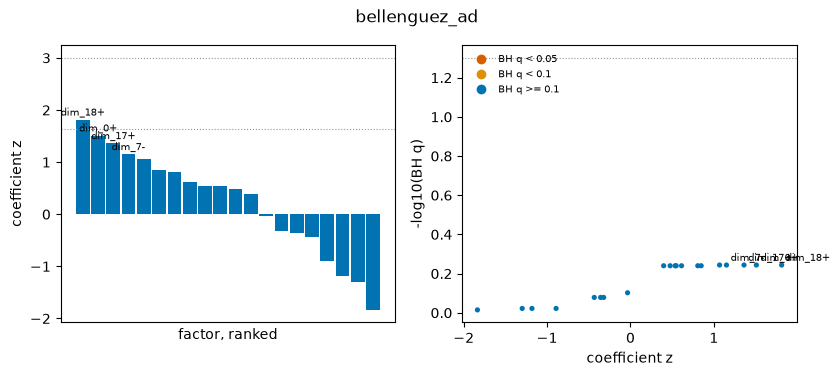

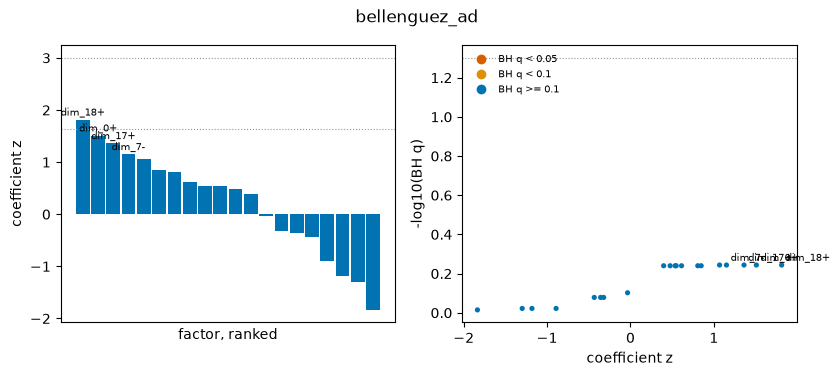

In [14]:
from scads_drvi.pl.enrichment import heritability_landscape, score_by_group
from scads_drvi.pl.frugal import box_stats
from scads_drvi.pl.umap import umap_continuous

fig, _ = heritability_landscape(arm, trait="bellenguez_ad")
fig


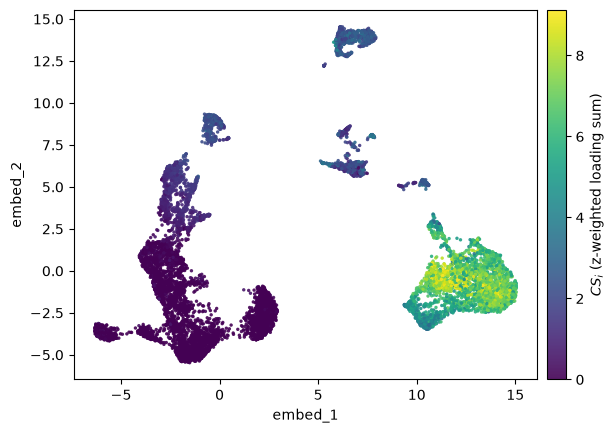

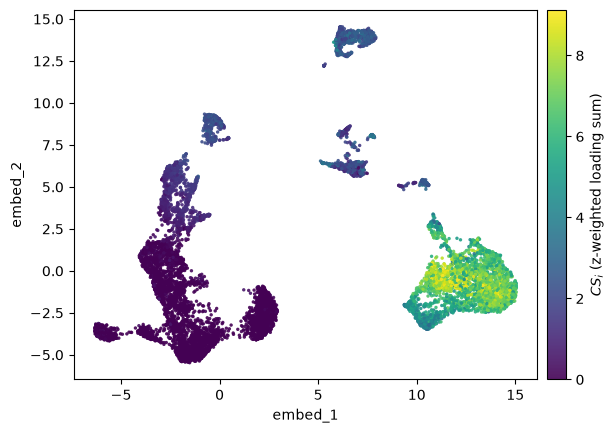

In [15]:
fig, _ = umap_continuous(
    cells, "score", x="embed_1", y="embed_2", colorbar_label=scores.label,
)
fig


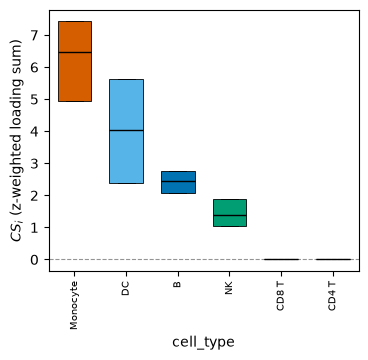

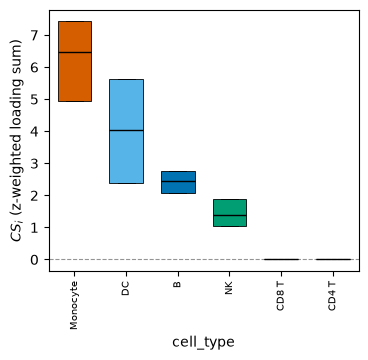

In [16]:
box_stats_frame = box_stats(cells["score"], cells["cell_type"].astype(str), min_n=10)
fig, _ = score_by_group(
    box_stats_frame, group_label="cell_type", value_label=scores.label, null=scores.null,
)
fig


## Where DRVI's own tools take over

Everything past `embed` is also a real `scvi.external.DRVI` model, so DRVI's and
`drvi-py`'s own interpretability functions apply directly --
`drvi.utils.pl.plot_latent_dims_in_umap`, `plot_latent_dimension_stats`, and the
model's `get_effect_of_splits_within_distribution`/`_out_of_distribution` (used above
to rank each factor's top peaks) and `calculate_interpretability_scores`. `scads-drvi`
wraps none of these a second time -- see the [DRVI docs](https://drvi.readthedocs.io/).
